In [1]:
import numpy as np # operations mathematiques
import numpy.random as npr # simulation d ' alea
import matplotlib.pyplot as plt # plot
import math 
import tabata as tbt
import pandas as pd
import os

In [2]:
pip install anywidget


Note: you may need to restart the kernel to use updated packages.


In [3]:
storename = "croisiere.h5"
ds_croisiere = tbt.Opset(storename) 
storename = "decollage.h5"
ds_decollage = tbt.Opset(storename) 

In [4]:
for f in ["extract_croisiere.h5","extract_decollage.h5"]:
    if os.path.exists(f):
        os.remove(f)
ds_clean_croisiere = tbt.Opset("extract_croisiere.h5")
ds_clean_decollage = tbt.Opset("extract_decollage.h5")

for i in np.arange(100):
        df = ds_croisiere[i]
        ds_clean_croisiere.put(df)

for i in np.arange(100):
        df = ds_decollage[i]
        ds_clean_decollage.put(df)


    

In [9]:
ds_clean_decollage.plot()


In [12]:
ds_clean_decollage[0].columns

Index(['ALT', 'EGT_1 [DEG C]', 'EGT_2 [DEG C]', 'FMV_1 [MM]', 'FMV_2 [MM]',
       'HPTACC_1 [%]', 'HPTACC_2 [%]', 'M [MACH]', 'N1_1 [% RPM]',
       'N1_2 [% RPM]', 'N2_1 [% RPM]', 'N2_2 [% RPM]', 'NAIV_1 [BOOL]',
       'NAIV_2 [BOOL]', 'P0_1 [PSIA]', 'P0_2 [PSIA]', 'PRV_1 [BOOL]',
       'PRV_2 [BOOL]', 'PS3_1 [PSIA]', 'PS3_2 [PSIA]', 'PT2_1 [MBAR]',
       'PT2_2 [MBAR]', 'P_OIL_1 [PSI]', 'P_OIL_2 [PSI]', 'Q_1 [LB/H]',
       'Q_2 [LB/H]', 'T1_1 [DEG C]', 'T1_2 [DEG C]', 'T2_1 [DEG C]',
       'T2_2 [DEG C]', 'T3_1 [DEG C]', 'T3_2 [DEG C]', 'T5_1 [DEG C]',
       'T5_2 [DEG C]', 'TAT [DEG C]', 'TBV_1 [%]', 'TBV_2 [%]',
       'TCASE_1 [DEG C]', 'TCASE_2 [DEG C]', 'TLA_1 [DEG]', 'TLA_2 [DEG]',
       'T_OIL_1 [DEG C]', 'T_OIL_2 [DEG C]', 'VBV_1 [MM]', 'VBV_2 [MM]',
       'VIB_AN1_1 [MILS]', 'VIB_AN1_2 [MILS]', 'VIB_AN2_1 [IPS]',
       'VIB_AN2_2 [IPS]', 'VIB_BN1_1 [MILS]', 'VIB_BN1_2 [MILS]',
       'VIB_BN2_1 [IPS]', 'VIB_BN2_2 [IPS]', 'VSV_1 [MM]', 'VSV_2 [MM]', 'CR',
       'DE

In [5]:
from sklearn.ensemble import RandomForestRegressor 

In [6]:
var = ["ALT", "M [MACH]","N1_1 [% RPM]","N2_1 [% RPM]","T_OIL_1 [DEG C]"]



In [7]:
ds_2d = pd.concat([vol for vol in ds_clean_decollage])
X_train =  ds_2d[var]
Y_train = ds_2d

model = RandomForestRegressor(n_estimators=100)
model.fit(X_train, Y_train)

# Étape 3 : On lui demande de "reconstruire" les données
predictions = model.predict(X_train)
df_res = pd.DataFrame(predictions, columns=Y_train.columns)


In [8]:
ds_2d_1 = pd.concat([vol for vol in ds_clean_croisiere])
X_train_1 =  ds_2d_1[var]
Y_train_1 = ds_2d_1

model = RandomForestRegressor(n_estimators=10)
model.fit(X_train_1, Y_train_1)

# Étape 3 : On lui demande de "reconstruire" les données
predictions_1 = model.predict(X_train_1)
df_res_1 = pd.DataFrame(predictions_1, columns=Y_train_1.columns)

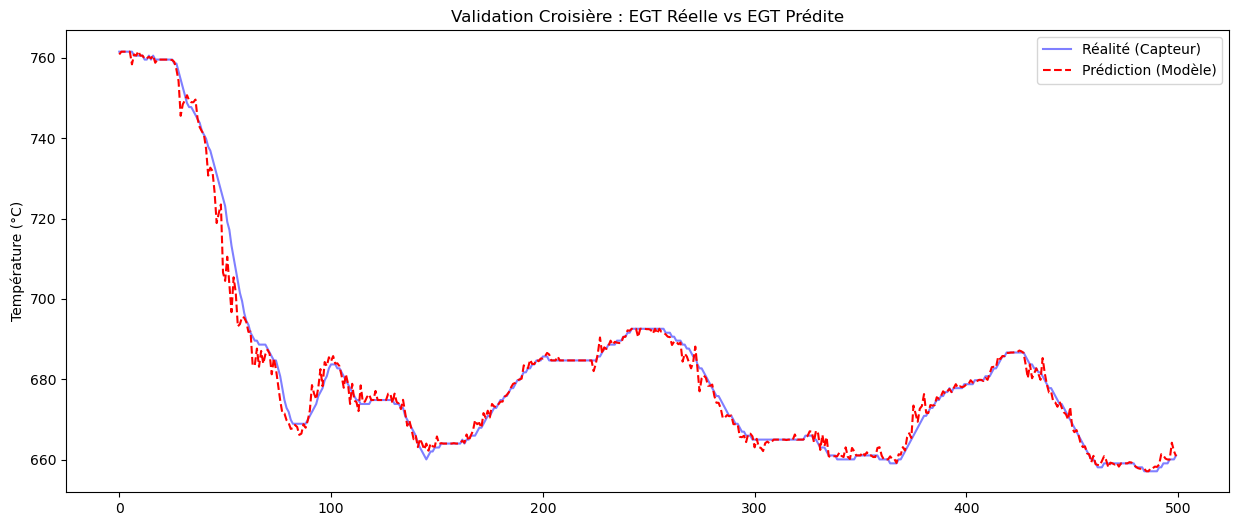

In [13]:
"""
plt.figure(figsize=(15, 6))
plt.plot(Y_train_1['EGT_1 [DEG C]'].values[:500], label='Réalité (Capteur)', color='blue', alpha=0.5)
plt.plot(df_res_1['EGT_1 [DEG C]'].values[:500], label='Prédiction (Modèle)', color='red', linestyle='--')

plt.title("Validation Croisière : EGT Réelle vs EGT Prédite")
plt.ylabel("Température (°C)")
plt.legend()
plt.show()
"""